# Visium HD Sample Split — Interactive Walkthrough

This notebook demonstrates how to split multiple tissue samples/cores
in a Visium HD Tissue Array using **bin-grid connected components**.

No H&E image processing needed — all operations are on the `array_row × array_col` grid.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
from PIL import Image
from scipy import sparse
from scipy.spatial import cKDTree
from skimage.measure import label, regionprops
from skimage.morphology import binary_opening, remove_small_objects, disk
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

print("All imports OK")

All imports OK


---
## 1. Set parameters

In [ ]:
# ═══════════════════════════════════════
# Config — modify these
# ═══════════════════════════════════════

BASE = Path("/path/to/visium_hd_data")  # Root dir with spatial/ + binned_outputs/
BIN_SIZE = "016um"                        # 002um | 008um | 016um

# ——— Component detection ———
MIN_BINS = 80          # Drop components smaller than this
MIN_COUNTS = 1.0        # Bin must have >= this many UMI to be foreground
OPEN_RADIUS = 1         # Opening radius to break thin bridges (0 = off)
CONNECTIVITY = 1        # 1 = 4-neighbor, 2 = 8-neighbor

# ——— Post-processing ———
EXPECTED_SAMPLES = 3    # Set to known N, or 0 to auto-detect
SIZE_PRIOR = False       # Auto-estimate sample size (used if EXPECTED_SAMPLES=0)

# ——— Rescue ———
NO_RESCUE = False
RESCUE_MAX_DIST = 4

# ——— Merge fragments ———
MERGE_MAX_DIST = 80     # Max grid distance to merge a fragment to major
KEEP_FAR_ISLANDS = False

print(f"bin={BIN_SIZE}, expected_samples={EXPECTED_SAMPLES}, open_radius={OPEN_RADIUS}")

bin=016um, expected_samples=3, open_radius=1


---
## 2. Load data

In [9]:
def _first_existing(paths, required=True):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    if required:
        raise FileNotFoundError("Not found: " + ", ".join(str(p) for p in paths))
    return None

def _matrix_row_sum(x):
    s = x.sum(axis=1)
    if sparse.issparse(s):
        return np.asarray(s).ravel()
    if hasattr(s, "A1"):
        return s.A1
    return np.asarray(s).ravel()

# Load
bin_dir = BASE / "binned_outputs" / f"square_{BIN_SIZE}"
matrix_h5 = _first_existing([bin_dir / "filtered_feature_bc_matrix.h5",
                              bin_dir / "raw_feature_bc_matrix.h5"])
pos_path = _first_existing([bin_dir / "spatial" / "tissue_positions.parquet"])
sf_path = _first_existing([bin_dir / "spatial" / "scalefactors_json.json"])
img_path = _first_existing([BASE / "spatial" / "tissue_hires_image.png"], required=False)

adata = sc.read_10x_h5(matrix_h5)
if not adata.var_names.is_unique:
    adata.var_names_make_unique()

pos = pd.read_parquet(pos_path)
with open(sf_path) as f:
    sf = json.load(f)

img = np.array(Image.open(img_path).convert("RGB")) if img_path else None

print(f"AnnData:  {adata.n_obs:,} bins × {adata.n_vars:,} genes")
print(f"Positions: {len(pos):,} rows")
if img is not None:
    print(f"Image:     {img.shape[1]}×{img.shape[0]}")

AnnData:  328,840 bins × 18,085 genes
Positions: 477,481 rows
Image:     6000×3385


---
## 3. Build foreground bin grid

Grid shape:     691×689 [col×row]
Foreground:     328,440 / 328,840 bins


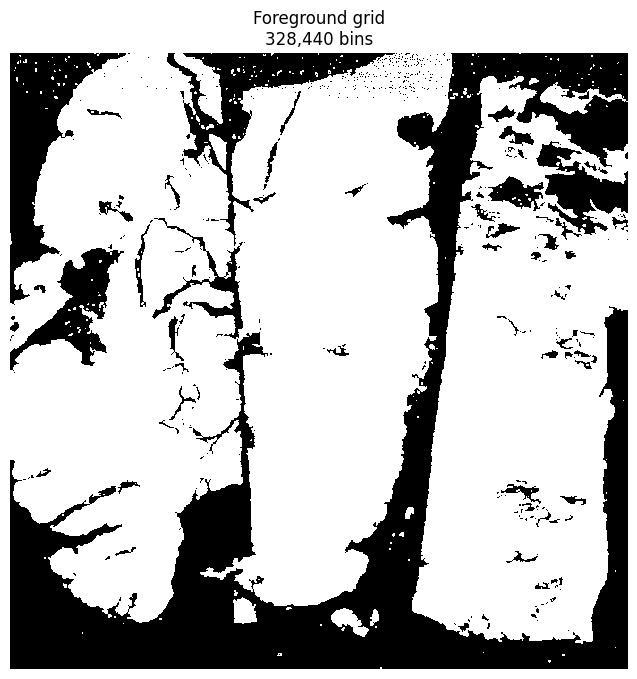

In [10]:
# Align barcodes
pos = pos.set_index("barcode", drop=False)
common = [bc for bc in adata.obs_names if bc in pos.index]
pos = pos.loc[common].copy()
adata = adata[common].copy()

counts = _matrix_row_sum(adata.X)
in_tissue = pos["in_tissue"].to_numpy().astype(int) == 1
count_ok = counts >= MIN_COUNTS
foreground = in_tissue & count_ok

array_row = pos["array_row"].astype(int).to_numpy()
array_col = pos["array_col"].astype(int).to_numpy()

# Build 2D grid
r0, c0 = int(array_row.min()), int(array_col.min())
rr = array_row - r0
cc = array_col - c0
grid_shape = (int(rr.max()) + 1, int(cc.max()) + 1)
fg_grid = np.zeros(grid_shape, dtype=bool)
fg_grid[rr[foreground], cc[foreground]] = True

print(f"Grid shape:     {grid_shape[1]}×{grid_shape[0]} [col×row]")
print(f"Foreground:     {foreground.sum():,} / {len(foreground):,} bins")

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(fg_grid, cmap="gray", interpolation="nearest")
ax.set_title(f"Foreground grid\n{fg_grid.sum():,} bins")
ax.axis("off")
plt.show()

---
## 4. Optional opening + connected components

Opening: disk(1)
  bins removed: 1893
Components:     11 (>80 bins)
  component 1: 110,851 bins
  component 2: 1,703 bins
  component 3: 110,762 bins
  component 4: 99,262 bins
  component 5: 1,257 bins
  component 6: 443 bins
  component 7: 133 bins
  component 8: 91 bins
  component 9: 598 bins
  component 10: 651 bins
  component 11: 112 bins


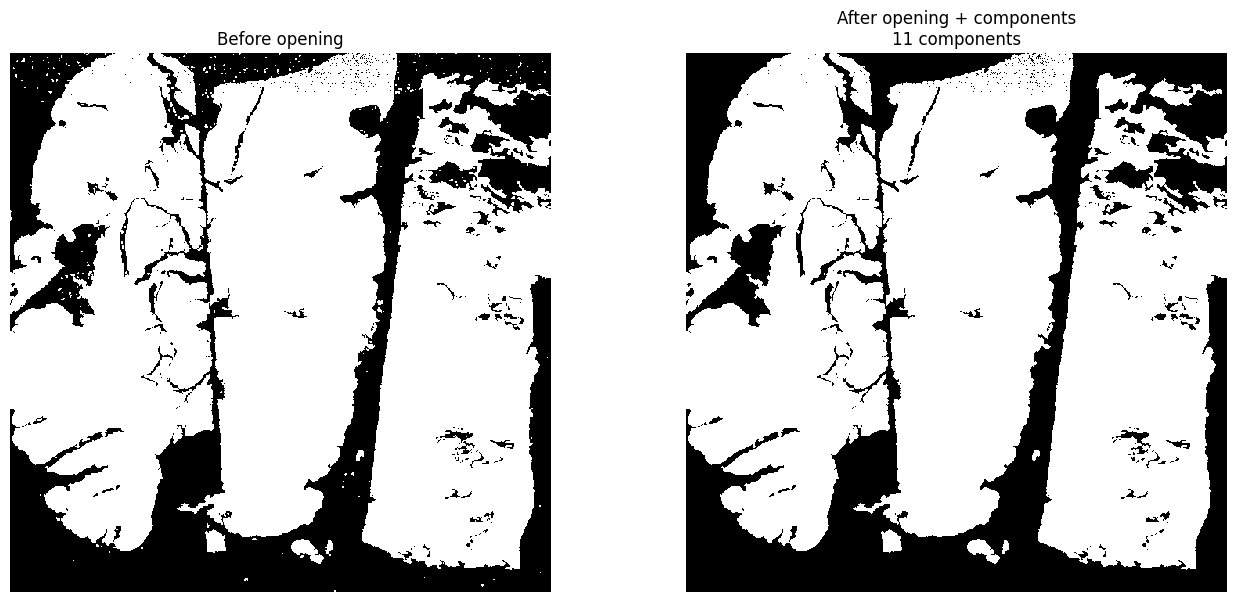

In [11]:
work = fg_grid.copy()

if OPEN_RADIUS > 0:
    print(f"Opening: disk({OPEN_RADIUS})")
    before = work.sum()
    work = binary_opening(work, footprint=disk(OPEN_RADIUS))
    print(f"  bins removed: {before - work.sum():.0f}")

# Connected components
raw_lab = label(work, connectivity=CONNECTIVITY)

# Assign initial labels to foreground bins
provisional = np.zeros(len(pos), dtype=np.int32)
provisional[foreground] = raw_lab[rr[foreground], cc[foreground]]

# Filter small components
raw_ids, raw_counts = np.unique(provisional[provisional > 0], return_counts=True)
keep_ids = set(raw_ids[raw_counts >= MIN_BINS].tolist())
keep_grid = np.isin(raw_lab, list(keep_ids))
keep_grid = remove_small_objects(keep_grid, min_size=MIN_BINS)
lab = label(keep_grid, connectivity=CONNECTIVITY)

# Assign final labels
sample_id = np.zeros(len(pos), dtype=np.int32)
sample_id[foreground] = lab[rr[foreground], cc[foreground]]

ids, cnts = np.unique(sample_id[sample_id > 0], return_counts=True)
ids = ids[cnts >= MIN_BINS]
sample_id[~np.isin(sample_id, ids)] = 0

print(f"Components:     {len(ids)} (>{MIN_BINS} bins)")
for i, c in zip(ids, cnts[cnts >= MIN_BINS]):
    print(f"  component {i}: {c:,} bins")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(fg_grid, cmap="gray", interpolation="nearest")
axes[0].set_title("Before opening")
axes[1].imshow(keep_grid, cmap="gray", interpolation="nearest")
axes[1].set_title(f"After opening + components\n{len(ids)} components")
for ax in axes: ax.axis("off")
plt.show()

---
## 5. Rescue lost bins + fragment handling

In [12]:
# Rescue bins lost after opening
if not NO_RESCUE and np.any(sample_id > 0):
    assigned = sample_id > 0
    rescue_mask = in_tissue & (sample_id == 0) & count_ok
    if rescue_mask.any():
        assigned_xy = np.column_stack([array_row[assigned], array_col[assigned]])
        rescue_xy = np.column_stack([array_row[rescue_mask], array_col[rescue_mask]])
        tree = cKDTree(assigned_xy)
        dists, idxs = tree.query(rescue_xy, k=1)
        valid = dists <= RESCUE_MAX_DIST
        assigned_ids = sample_id[assigned]
        sample_id[np.where(rescue_mask)[0][valid]] = assigned_ids[idxs[valid]]
        print(f"Rescued: {valid.sum():,} / {rescue_mask.sum():,} bins")

# ——— Fragment merge (if EXPECTED_SAMPLES set) ———
if EXPECTED_SAMPLES > 0:
    ids, cnts = np.unique(sample_id[sample_id > 0], return_counts=True)
    count_map = {int(i): int(c) for i, c in zip(ids, cnts)}
    sorted_ids = sorted(count_map, key=lambda x: count_map[x], reverse=True)
    major_ids = set(sorted_ids[:EXPECTED_SAMPLES])
    fragment_ids = set(sorted_ids[EXPECTED_SAMPLES:])
    
    print(f"Major components: {len(major_ids)}")
    print(f"Fragments to merge: {len(fragment_ids)}")
    
    if fragment_ids:
        major_xy = []
        major_id_list = []
        for mid in major_ids:
            m = sample_id == mid
            major_xy.append([float(np.median(array_row[m])), float(np.median(array_col[m]))])
            major_id_list.append(mid)
        tree = cKDTree(np.array(major_xy))
        
        for fid in fragment_ids:
            fm = sample_id == fid
            fc = np.array([float(np.median(array_row[fm])), float(np.median(array_col[fm]))])
            dist, idx = tree.query(fc)
            if dist <= MERGE_MAX_DIST or not KEEP_FAR_ISLANDS:
                sample_id[sample_id == fid] = major_id_list[idx]
                print(f"  merged fragment {fid} ({count_map[fid]} bins) → component {major_id_list[idx]}")

# Renumber left-to-right
old_ids = [int(x) for x in np.unique(sample_id) if x > 0]
old_ids = sorted(old_ids, key=lambda x: float(np.median(array_col[sample_id == x])))
remap = {old: new for new, old in enumerate(old_ids, start=1)}
sample_id = np.array([remap.get(int(x), 0) for x in sample_id], dtype=np.int32)

pos["sample_id"] = sample_id
pos["sample_name"] = [f"sample_{x:03d}" if x > 0 else "background" for x in sample_id]

print(f"\nFinal samples: {len(old_ids)}")
for sid in sorted(np.unique(sample_id)):
    if sid > 0:
        print(f"  sample_{sid:03d}: {(sample_id==sid).sum():,} bins")

Rescued: 1,346 / 2,577 bins
Major components: 3
Fragments to merge: 8
  merged fragment 2 (1728 bins) → component 3
  merged fragment 5 (1299 bins) → component 4
  merged fragment 6 (446 bins) → component 3
  merged fragment 7 (135 bins) → component 4
  merged fragment 8 (94 bins) → component 4
  merged fragment 9 (606 bins) → component 1
  merged fragment 10 (663 bins) → component 4
  merged fragment 11 (122 bins) → component 4

Final samples: 3
  sample_001: 111,921 bins
  sample_002: 113,276 bins
  sample_003: 102,012 bins


---
## 6. Write back to AnnData

In [13]:
pos_i = pos.set_index("barcode", drop=False)
common = [bc for bc in adata.obs_names if bc in pos_i.index]
adata = adata[common].copy()
pos_i = pos_i.loc[common]

adata.obs["sample_id"] = pos_i["sample_id"].astype(int).values
adata.obs["sample"] = pos_i["sample_name"].astype(str).values
adata.obs["in_tissue"] = pos_i["in_tissue"].astype(int).values
adata.obs["array_row"] = pos_i["array_row"].astype(int).values
adata.obs["array_col"] = pos_i["array_col"].astype(int).values

# Spatial coordinates (hires)
sf_hires = float(sf.get("tissue_hires_scalef", 1.0))
adata.obs["pxl_row_in_hires"] = pos_i["pxl_row_in_fullres"].values * sf_hires
adata.obs["pxl_col_in_hires"] = pos_i["pxl_col_in_fullres"].values * sf_hires
adata.obsm["spatial"] = adata.obs[["pxl_col_in_hires", "pxl_row_in_hires"]].values

print(f"AnnData: {adata.shape}")
print(f"obs columns: {list(adata.obs.columns)}")
print(f"\nSample distribution:")
print(adata.obs["sample"].value_counts())

AnnData: (328840, 18085)
obs columns: ['sample_id', 'sample', 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_hires', 'pxl_col_in_hires']

Sample distribution:
sample
sample_002    113276
sample_001    111921
sample_003    102012
background      1631
Name: count, dtype: int64


---
## 7. Visualize results

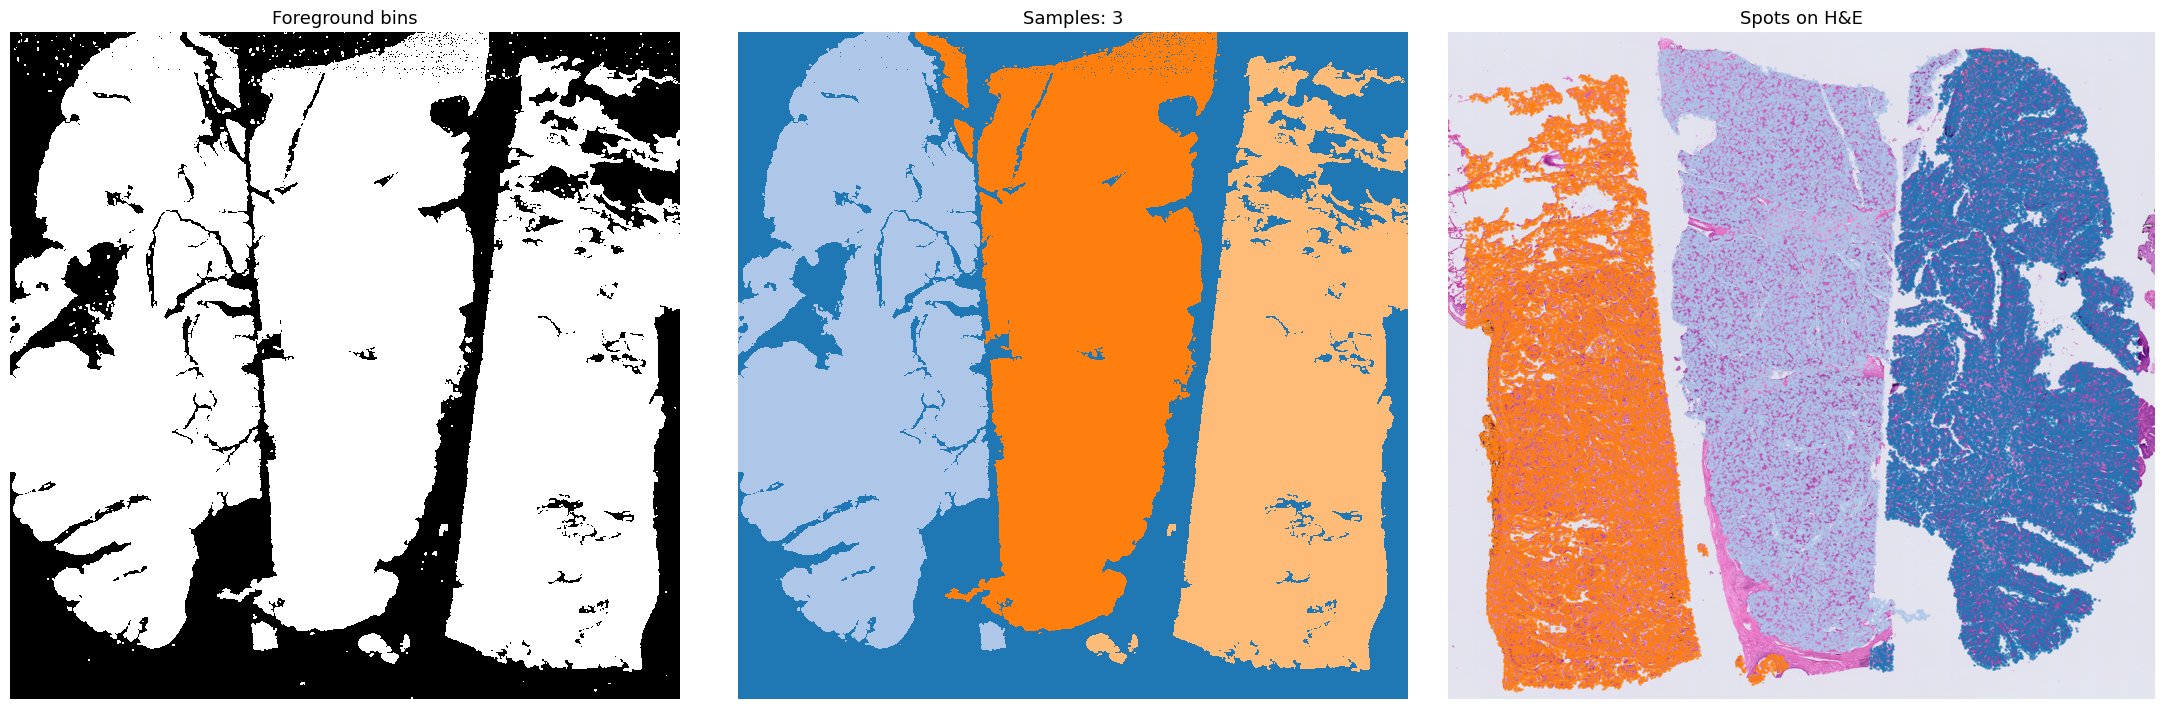

Done.


In [14]:
# Build label grid for display
label_grid = np.zeros_like(raw_lab, dtype=np.int32)
for sid in sorted(np.unique(sample_id)):
    if sid > 0:
        m = sample_id == sid
        label_grid[rr[m], cc[m]] = sid

n_samples = len(old_ids)
colors = plt.cm.tab20(np.linspace(0, 1, max(n_samples, 20)))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: foreground grid
axes[0].imshow(fg_grid, cmap="gray", interpolation="nearest")
axes[0].set_title("Foreground bins", fontsize=13)
axes[0].axis("off")

# Panel 2: label grid
axes[1].imshow(label_grid, cmap="tab20", interpolation="nearest", vmin=0, vmax=20)
axes[1].set_title(f"Samples: {n_samples}", fontsize=13)
axes[1].axis("off")

# Panel 3: H&E overlay
if img is not None and "pxl_col_in_hires" in adata.obs.columns:
    x = adata.obs["pxl_col_in_hires"].values
    y = adata.obs["pxl_row_in_hires"].values
    in_sample = sample_id > 0
    
    # Crop image to relevant area
    margin = 80
    x1 = max(0, int(np.nanmin(x[in_sample])) - margin)
    x2 = min(img.shape[1], int(np.nanmax(x[in_sample])) + margin)
    y1 = max(0, int(np.nanmin(y[in_sample])) - margin)
    y2 = min(img.shape[0], int(np.nanmax(y[in_sample])) + margin)
    
    axes[2].imshow(img[y1:y2, x1:x2])
    
    # Subsample for speed
    idx = np.where(in_sample)[0]
    if len(idx) > 100_000:
        idx = np.random.default_rng(0).choice(idx, size=100_000, replace=False)
    
    for sid in sorted(np.unique(sample_id)):
        if sid <= 0: continue
        m = idx[sample_id[idx] == sid]
        axes[2].scatter(x[m] - x1, y[m] - y1, s=1,
                       color=colors[(sid-1) % len(colors)], alpha=0.55, rasterized=True)
    axes[2].set_title("Spots on H&E", fontsize=13)
    axes[2].axis("off")
else:
    axes[2].text(0.5, 0.5, "No H&E image", ha="center", va="center", transform=axes[2].transAxes)
    axes[2].axis("off")

plt.tight_layout()
plt.show()
print("Done.")

---
## 8. Save outputs

In [ ]:
out_dir = BASE / "_sample_split" / f"square_{BIN_SIZE}" / f"N{len(old_ids)}"
out_dir.mkdir(parents=True, exist_ok=True)

# AnnData
adata.write_h5ad(out_dir / "visium_hd_sample_split.h5ad")

# Assignment table
pos[["barcode", "in_tissue", "sample_id", "sample_name"]].to_csv(
    out_dir / "spot_sample_assignment.csv", index=False
)

# Summary
rows = []
counts = _matrix_row_sum(adata.X)
for sid in sorted(np.unique(sample_id)):
    if sid <= 0: continue
    m = sample_id == sid
    rows.append({"sample_id": sid, "sample_name": f"sample_{sid:03d}",
                 "n_bins": int(m.sum()),
                 "total_counts": float(counts[m].sum()),
                 "median_counts": float(np.median(counts[m]))})
pd.DataFrame(rows).to_csv(out_dir / "sample_summary.csv", index=False)

# Label grid
np.save(out_dir / "sample_label_grid.npy", label_grid)

print(f"Saved to {out_dir}")
print(f"  visium_hd_sample_split.h5ad")
print(f"  spot_sample_assignment.csv")
print(f"  sample_summary.csv")
print(f"  sample_label_grid.npy")